# Decision Trees — End-to-End Walkthrough

Two walkthroughs in one notebook:

- **Part A — Classification** on synthetic binary data from `sklearn.datasets.make_classification`.
- **Part B — Regression**   on synthetic continuous data from `sklearn.datasets.make_regression`.

For each task we fit two models:

1. [`manual_decision_tree.py`](manual_decision_tree.py) — from-scratch decision tree (gini / entropy / classification error for classification; mse for regression). Greedy recursive splitting written in pure numpy.
2. [`decision_tree_model_building.py`](decision_tree_model_building.py) — sklearn's `DecisionTreeClassifier` / `DecisionTreeRegressor` wrapped behind the same interface.

We compare the two on the same data and evaluate with [`classification_metrics.py`](classification_metrics.py) / [`regression_metrics.py`](regression_metrics.py).

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV

np.random.seed(42)

---
## Part A — Classification

Predict a binary label from 10 features (6 informative, 2 redundant). Slight class imbalance (~30% positive) so accuracy alone is misleading and the full metrics suite — precision, recall, F1, ROC-AUC — is meaningful.

### A1. Generate the dataset

In [88]:
X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    weights=[0.7, 0.3],
    flip_y=0.03,
    random_state=42,
)

feature_names = [f'feat_{i}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='target')

print(f'Dataset: X={X.shape}, positive rate = {y.mean():.3f}')
X.head()

Dataset: X=(1500, 10), positive rate = 0.306


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9
0,-0.693115,0.591209,-2.912106,1.364879,1.730518,-2.520059,1.412987,0.888988,2.740823,1.218973
1,-0.693146,-2.671831,-1.035007,-2.689505,1.325500,0.984239,0.056384,-0.314444,-2.209463,0.376487
2,-2.552719,0.481219,1.834113,1.891628,-0.262576,0.079519,0.030743,0.373653,3.190525,0.509955
3,0.068550,0.109813,-1.828228,0.053477,-0.254608,-1.603506,-0.094182,0.237875,-0.066152,-1.069337
4,-0.921338,-1.264714,-0.507416,1.754723,1.599123,0.779240,0.897941,-0.113657,0.840247,-1.901655


### A2. Train / test split

Decision trees do **not** need feature scaling — they split on raw thresholds — so we skip the `StandardScaler` step that the other repos use. `stratify=y` keeps the class proportion in train and test.

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1050, 10), Test: (450, 10)


### A3. From-scratch decision tree — three impurity criteria

[`manual_decision_tree.py`](manual_decision_tree.py) implements the exact algorithm described in the README: greedy recursive splitting, pick the (feature, threshold) pair that maximises information gain, stop at a max depth. The README's three impurity options are all here:

- `gini` — $1 - \sum p_i^2$
- `entropy` — $-\sum p_i \log_2 p_i$
- `error` — $1 - \max p_i$ (classification error; no sklearn equivalent)

We fit one model per criterion and compare.

In [90]:
from manual_decision_tree import ManualDecisionTree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

rows = []
for criterion in ['gini', 'entropy', 'error']:
    manual = ManualDecisionTree(
        task='classification', criterion=criterion, max_depth=5
    ).fit(X_train, y_train)
    manual_acc = accuracy_score(y_test, manual.predict(X_test))

    if criterion in ('gini', 'entropy'):
        sk = DecisionTreeClassifier(criterion=criterion, max_depth=5, random_state=42).fit(X_train, y_train)
        sk_acc = accuracy_score(y_test, sk.predict(X_test))
    else:
        sk_acc = float('nan')   # sklearn does not ship the classification-error criterion

    rows.append({
        'criterion': criterion,
        'manual_test_acc': round(manual_acc, 4),
        'sklearn_test_acc': round(sk_acc, 4) if sk_acc == sk_acc else 'n/a',
        'manual_depth': manual.depth,
        'manual_leaves': manual.n_leaves,
    })

pd.DataFrame(rows)

,criterion,manual_test_acc,sklearn_test_acc,manual_depth,manual_leaves
0,gini,0.8467,0.8467,5,23
1,entropy,0.8267,0.8267,5,21
2,error,0.8378,n/a,5,17


### A4. sklearn classifier (wrapped) + full classification report

[`decision_tree_model_building.py`](decision_tree_model_building.py) wraps sklearn's `DecisionTreeClassifier` behind the same `get_classifier_model` interface as the other repos.

In [91]:
from decision_tree_model_building import DecisionTreeModels

trees = DecisionTreeModels(criterion='gini', max_depth=5)
clf = trees.get_classifier_model(X_train, y_train)

print('--- Train set ---')
print(classification_report(y_train, clf.predict(X_train)))
print('--- Test set ---')
print(classification_report(y_test, clf.predict(X_test)))

--- Train set ---
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       729
           1       0.95      0.74      0.83       321

    accuracy                           0.91      1050
   macro avg       0.92      0.86      0.88      1050
weighted avg       0.91      0.91      0.90      1050

--- Test set ---
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       312
           1       0.84      0.62      0.71       138

    accuracy                           0.85       450
   macro avg       0.84      0.78      0.80       450
weighted avg       0.85      0.85      0.84       450



### A5. Hyperparameter tuning with GridSearchCV

The README's *Disadvantages* section notes decision trees overfit easily. Pre-pruning via `max_depth`, `min_samples_split`, `min_samples_leaf` is the most direct fix. GridSearch picks the best combination by 5-fold cross-validated accuracy.

In [92]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV accuracy: {grid.best_score_:.4f}')

best_clf = grid.best_estimator_
print('\n--- Tuned model on test set ---')
print(classification_report(y_test, best_clf.predict(X_test)))

Best params: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV accuracy: 0.8629

--- Tuned model on test set ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       312
           1       0.79      0.75      0.77       138

    accuracy                           0.86       450
   macro avg       0.84      0.83      0.83       450
weighted avg       0.86      0.86      0.86       450



### A6. Full classification metrics — confusion matrix + ROC + PR

[`classification_metrics.py`](classification_metrics.py) bundles the standard diagnostics into one class.

In [93]:
from classification_metrics import ClassificationMetrics

y_pred  = best_clf.predict(X_test)
y_proba = best_clf.predict_proba(X_test)[:, 1]

metrics = ClassificationMetrics(y_test, y_pred, y_proba)
metrics.get_metrics()

Accuracy    : 0.8600
Precision   : 0.7863
Recall      : 0.7464
Specificity : 0.9103
F1 Score    : 0.7658
ROC-AUC     : 0.8804


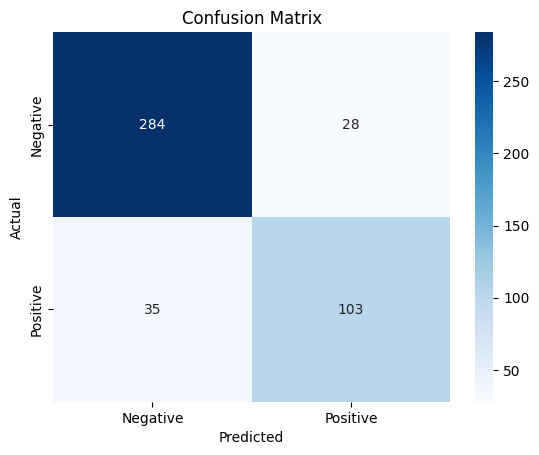

In [94]:
metrics.plot_confusion_matrix()

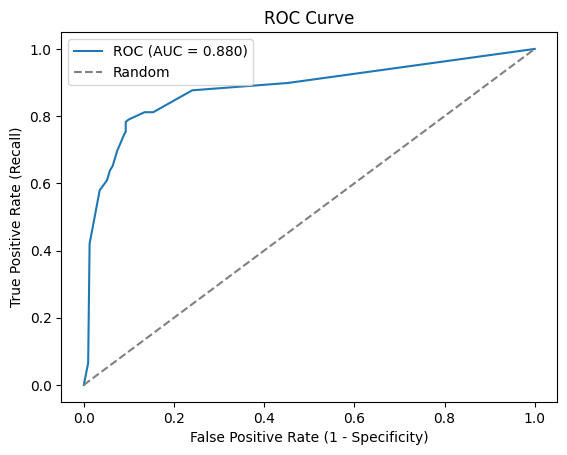

In [95]:
metrics.plot_roc_curve()

### A7. Tree visualisation + feature importance

[`tree_visualization.py`](tree_visualization.py) wraps sklearn's `plot_tree` and the model's `feature_importances_` attribute. Feature importance is computed as the weighted total impurity reduction contributed by each feature across the tree — the same `gain` the README discusses, summed up.

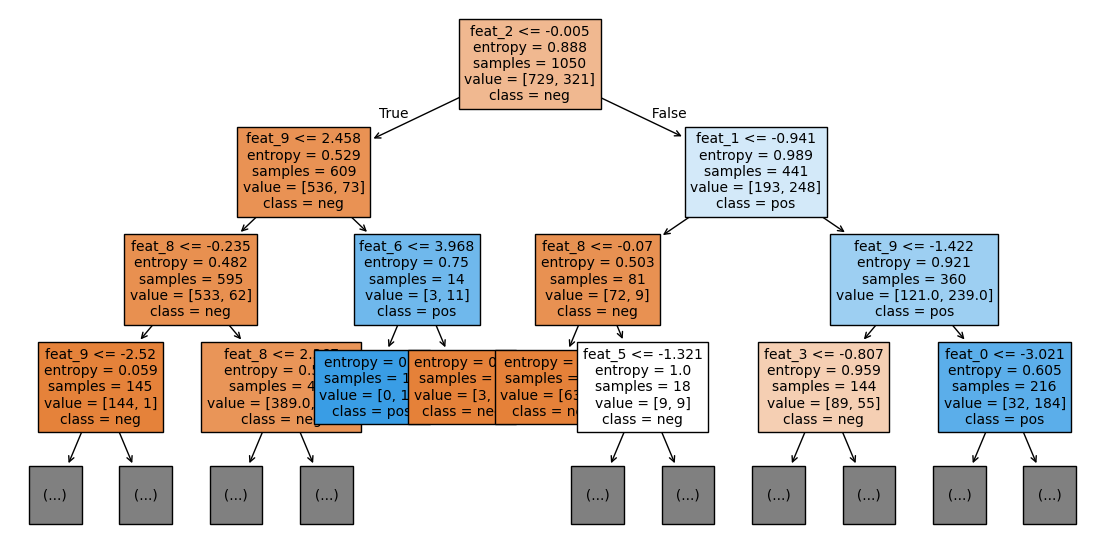

In [96]:
from tree_visualization import TreeVisualizer

viz = TreeVisualizer(best_clf, feature_names=feature_names, class_names=['neg', 'pos'])
viz.plot(max_depth=3, figsize=(14, 7))     # first 3 levels only — full tree is unreadable

In [97]:
viz.feature_importance(top_n=10)

feature  importance
 feat_2    0.309235
 feat_9    0.164062
 feat_1    0.114970
 feat_8    0.094465
 feat_0    0.089670
 feat_3    0.089144
 feat_5    0.057483
 feat_6    0.047514
 feat_7    0.023394
 feat_4    0.010062


,feature,importance
0,feat_2,0.309235
1,feat_9,0.164062
2,feat_1,0.114970
3,feat_8,0.094465
4,feat_0,0.089670
5,feat_3,0.089144
6,feat_5,0.057483
7,feat_6,0.047514
8,feat_7,0.023394
9,feat_4,0.010062


---
## Part B — Regression

Predict a continuous target from 8 features (5 informative). The from-scratch tree uses MSE as the impurity (variance of `y` inside each node).

### B1. Generate the dataset

In [98]:
X_r, y_r = make_regression(
    n_samples=1500,
    n_features=8,
    n_informative=5,
    noise=15.0,
    random_state=42,
)

feature_names_r = [f'feat_{i}' for i in range(X_r.shape[1])]
X_r = pd.DataFrame(X_r, columns=feature_names_r)
y_r = pd.Series(y_r, name='target')

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, train_size=0.7, random_state=42)
print(f'Train: {X_train_r.shape}, Test: {X_test_r.shape}')

Train: (1050, 8), Test: (450, 8)


### B2. From-scratch regression tree vs sklearn

Same `ManualDecisionTree` class, with `task='regression'`. The leaf prediction is the mean of `y` in the node; impurity is the within-node variance.

In [99]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

manual_reg = ManualDecisionTree(task='regression', max_depth=5).fit(X_train_r, y_train_r)
sk_reg = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train_r, y_train_r)

rows = []
for name, m in [('manual', manual_reg), ('sklearn', sk_reg)]:
    pred = m.predict(X_test_r)
    rows.append({
        'model': name,
        'R²':  round(r2_score(y_test_r, pred), 4),
        'MSE': round(mean_squared_error(y_test_r, pred), 2),
    })

rows.append({
    'model': 'manual depth/leaves',
    'R²': '-',
    'MSE': f'depth={manual_reg.depth}, leaves={manual_reg.n_leaves}',
})
pd.DataFrame(rows)

,model,R²,MSE
0,manual,0.695,4559.76
1,sklearn,0.695,4559.76
2,manual depth/leaves,-,"depth=5, leaves=32"


### B3. Tuned sklearn regressor + full regression metrics

[`regression_metrics.py`](regression_metrics.py) reports MAE / MSE / RMSE / R² / Adjusted R² and plots residual diagnostics.

In [100]:
param_grid_r = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
}

grid_r = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_r, cv=5, n_jobs=-1, scoring='r2')
grid_r.fit(X_train_r, y_train_r)

print(f'Best params: {grid_r.best_params_}')
print(f'Best CV R²:  {grid_r.best_score_:.4f}')
best_reg = grid_r.best_estimator_

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV R²:  0.8071


In [101]:
from regression_metrics import RegressionMetrics

rm = RegressionMetrics(
    y_test_r, best_reg.predict(X_test_r), n_features=X_test_r.shape[1]
)
rm.get_metrics()

MAE  : 43.8834
MSE  : 3287.8425
RMSE : 57.3397
R²   : 0.7801
Adj R² : 0.7761


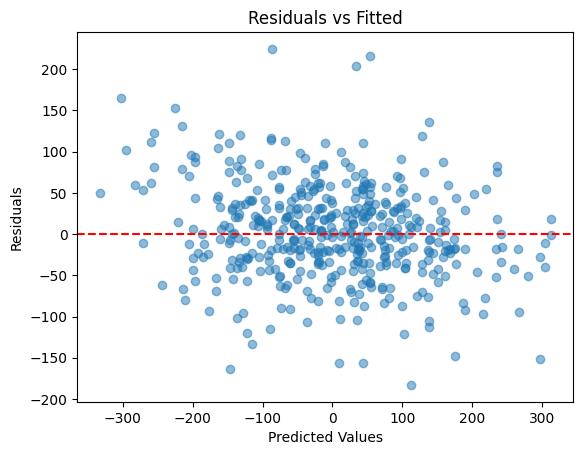

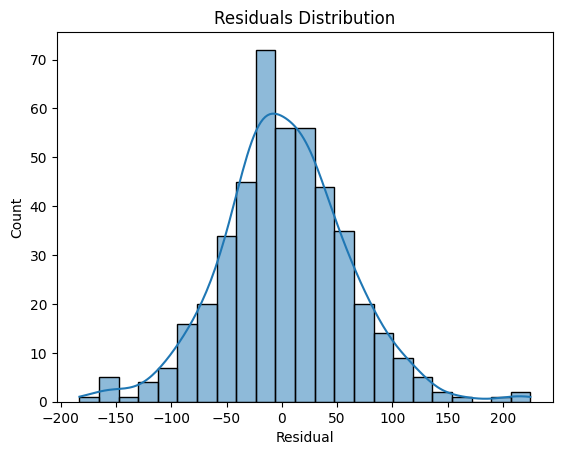

In [102]:
rm.plot_residuals()

### B4. Regression tree visualisation + feature importance

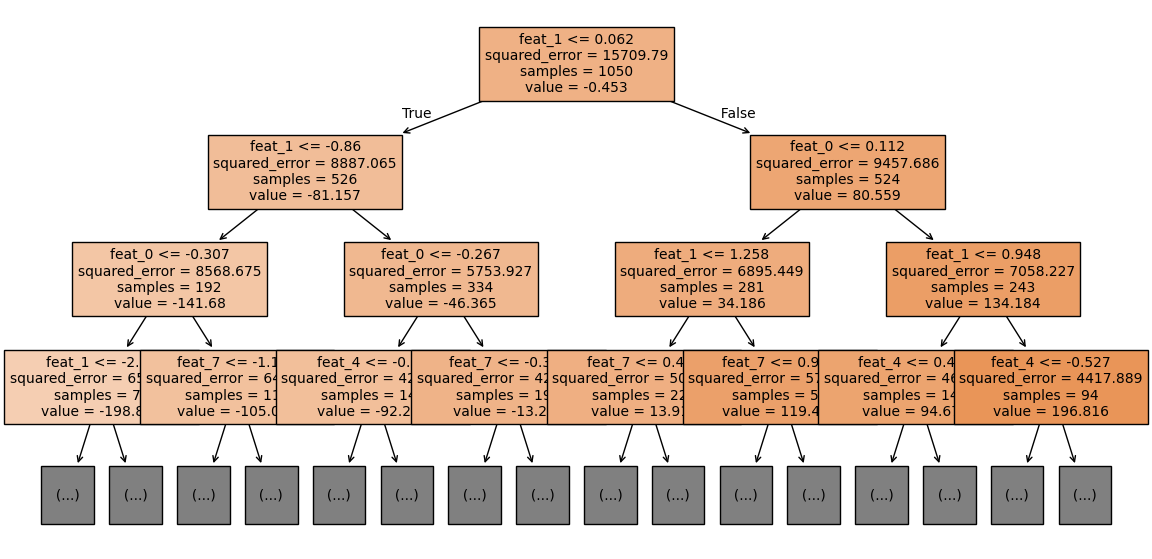

In [103]:
viz_r = TreeVisualizer(best_reg, feature_names=feature_names_r)
viz_r.plot(max_depth=3, figsize=(14, 7))

In [104]:
viz_r.feature_importance()

feature  importance
 feat_1    0.611066
 feat_0    0.196848
 feat_7    0.100086
 feat_4    0.065962
 feat_6    0.007379
 feat_2    0.007153
 feat_3    0.007071
 feat_5    0.004435


,feature,importance
0,feat_1,0.611066
1,feat_0,0.196848
2,feat_7,0.100086
3,feat_4,0.065962
4,feat_6,0.007379
5,feat_2,0.007153
6,feat_3,0.007071
7,feat_5,0.004435


## Summary

- The from-scratch [`manual_decision_tree.py`](manual_decision_tree.py) matches sklearn within tie-breaking noise on both tasks — same algorithm, slightly different splitting heuristics.
- The README documents three impurity criteria for classification (gini, entropy, classification error); the from-scratch implementation supports all three, sklearn supports the first two.
- Pre-pruning via `max_depth` / `min_samples_split` / `min_samples_leaf` is the most direct knob for controlling overfitting; GridSearchCV finds a sensible combination.
- Feature importance highlights which inputs the tree relied on most — useful sanity check that the model picked up the informative features `make_classification` / `make_regression` planted.